# Configuring the MISMIP ISSM model

This notebook integrates the logic from [`runme.py`](./runme.py) and [`Mismip.py`](./Mismip.py) into one readable workflow.

The main idea is:

- `runme.py` controls the experiment workflow: paths, model choice, mesh resolution, cluster target, pipeline stages, flow-equation branches, and solves.
- `Mismip.py` defines the physical model setup: geometry, friction, rheology, boundary conditions, forcing, constants, and initial conditions.

This notebook is written as a guide to the logical path. Some cells are illustrative and safe to read without launching an ISSM solve. The solve cells should only be run once the ISSM environment, Gadi paths, and previous model stages are set correctly.

## Workflow map

The model setup follows this sequence:

1. Choose the experiment family: resolution and basal friction style.
2. Choose the compute target: Gadi or local/generic.
3. Create an ISSM `organizer` to manage restartable stages.
4. Generate a mesh from `Domain.exp`.
5. Parameterize the mesh using `Mismip.py`.
6. Spin up the model with transient SSA relaxation.
7. Optionally continue the spin-up with restart stages.
8. Optionally extrude the model to 3D.
9. Run solver-comparison branches: SSA, MOLHO, HO, FS.
10. Optionally run enhanced-rheology or ESTAR branches.

A useful mental model: first create the physical experiment, then choose which stress-balance approximation to test.

## 1. Choose the experiment family

`runme.py` uses `modelnum` to choose both mesh resolution and basal friction type.

The current script sets:

```python
steps = [11]
modelnum = 1
```

That means `1km_viscous`, and only one selected organizer stage is intended to run.

In [ ]:
# Notebook representation of the model choices in runme.py
MODEL_CHOICES = {
    1: {"name": "1km_viscous", "hmax": 1000, "friction": "viscous"},
    2: {"name": "2km_viscous", "hmax": 2000, "friction": "viscous"},
    3: {"name": "1km_coulomb", "hmax": 1000, "friction": "coulomb"},
    4: {"name": "2km_coulomb", "hmax": 2000, "friction": "coulomb"},
    5: {"name": "500m_viscous", "hmax": 500, "friction": "viscous"},
    6: {"name": "500m_coulomb", "hmax": 500, "friction": "coulomb"},
    7: {"name": "200m_viscous", "hmax": 200, "friction": "viscous"},
    8: {"name": "200m_coulomb", "hmax": 200, "friction": "coulomb"},
    9: {"name": "10km_viscous", "hmax": 10000, "friction": "viscous"},
}

modelnum = 2
choice = MODEL_CHOICES[modelnum]
modelname = choice["name"]
hmax = choice["hmax"]
friction_style = choice["friction"]

choice

{'name': '2km_viscous', 'hmax': 2000, 'friction': 'viscous'}

### Choice consequences

This one number affects multiple later decisions:

- `hmax` controls mesh spacing in `bamg`.
- viscous cases keep the default friction created by `Mismip.py`.
- Coulomb cases replace the friction object during solve setup.
- the model name becomes part of the output directory and saved model prefix.

So changing `modelnum` is the simplest way to switch experiment families.

## 2. Prepare ISSM imports

The top of `runme.py` requires `ISSM_DIR` and then manually extends `sys.path` so ISSM Python modules can be imported.

This pattern is common in ISSM Python workflows because many modules live inside the ISSM source tree rather than in a normal Python package installed into the environment.

In [2]:
# This mirrors the setup in runme.py. Run this only in an environment where ISSM_DIR is set.
import os
import sys

issm_dir = os.getenv("ISSM_DIR")
if issm_dir is None:
    raise RuntimeError("ISSM_DIR is not set. Load/configure ISSM before running ISSM cells.")

sys.path.insert(0, os.path.join(issm_dir, "src", "m", "boundaryconditions"))
sys.path.insert(0, os.path.join(issm_dir, "src", "m", "classes"))
sys.path.insert(1, os.path.join(issm_dir, "src", "m", "classes", "clusters"))
sys.path.append(os.path.join(issm_dir, "src", "m", "contrib", "jr5971"))
sys.path.append(os.path.join(issm_dir, "bin"))
sys.path.append(os.path.join(issm_dir, "lib"))

issm_dir

'/g/data/vk83/apps/spack/0.22/release/linux-rocky8-x86_64/gcc-13.2.0/issm-git.2025.11.24_2025.11.24-pd55xlx56v5vuno2lshenunfddfvupnr'

## 3. Choose where the model runs

`runme.py` currently assumes `clustername = 'gadi'` and fills in a Gadi cluster object with hard-coded account paths.

This is one of the most user-specific parts of the script. Before running solves, check:

- the login username
- the NCI project code
- the ISSM source path
- the ISSM binary path
- the execution path on scratch
- the requested nodes, CPUs, and walltime

If those paths belong to another user, the notebook should be edited before launching jobs.

In [3]:
# Cluster choice from runme.py, adapted to the pyISSM tutorial style.
clustername = "gadi"

GADI_CONFIG = {
    "name": "gadi.nci.org.au",
    "login": "jr5971",
    "srcpath": "/g/data/au88/jr5971/ISSM",
    "rundir": "/g/data/au88/jr5971/MISMIP_ISSM/rundir",
    "project": "au88",
    "storage": "gdata/au88+gdata/vk83+gdata/xp65+scratch/au88",
    "numnodes": 1,
    "cpuspernode": 28,
    "memory_gb": 64,
    "queue": "normal",
    "time_minutes": 60*24,
    "analysis3_module": "conda/analysis3-26.02",
    "issm_module": "access-issm/2025.11.0",
    "moduleuse": [
        "/g/data/xp65/public/modules",
        "/g/data/vk83/modules",
    ],
    "moduleload": [
        "conda/analysis3-26.02",
        "access-issm/2025.11.0",
    ],
    "codepath": "/g/data/vk83/apps/spack/0.22/release/linux-rocky8-x86_64/gcc-13.2.0/issm-git.2025.11.24_2025.11.24-pd55xlx56v5vuno2lshenunfddfvupnr/bin",
    "executionpath": "/scratch/au88/jr5971/issm_runs",
}

GADI_CONFIG


{'name': 'gadi.nci.org.au',
 'login': 'jr5971',
 'srcpath': '/g/data/au88/jr5971/ISSM',
 'rundir': '/g/data/au88/jr5971/MISMIP_ISSM/rundir',
 'project': 'au88',
 'storage': 'gdata/au88+gdata/vk83+gdata/xp65+scratch/au88',
 'numnodes': 1,
 'cpuspernode': 28,
 'memory_gb': 64,
 'queue': 'normal',
 'time_minutes': 1440,
 'analysis3_module': 'conda/analysis3-26.02',
 'issm_module': 'access-issm/2025.11.0',
 'moduleuse': ['/g/data/xp65/public/modules', '/g/data/vk83/modules'],
 'moduleload': ['conda/analysis3-26.02', 'access-issm/2025.11.0'],
 'codepath': '/g/data/vk83/apps/spack/0.22/release/linux-rocky8-x86_64/gcc-13.2.0/issm-git.2025.11.24_2025.11.24-pd55xlx56v5vuno2lshenunfddfvupnr/bin',
 'executionpath': '/scratch/au88/jr5971/issm_runs'}

## 5. Stage dependency map

The useful way to read `runme.py` is as a dependency graph.

| Stage | Depends on | Purpose |
| --- | --- | --- |
| `Mesh_generation` | `Domain.exp` | Create the 2D finite-element mesh. |
| `Parameterization` | `Mesh_generation`, `Mismip.py` | Add geometry, materials, masks, forcing, and initial conditions. |
| `Transient_Steadystate` | `Parameterization` | Long SSA transient relaxation. |
| `Transient_steadystate2/3/4/5` | Previous transient stage | Continue relaxation from the last saved solution. |
| `Transient_extrude` | `Transient_steadystate3` | Extrude to a 3D mesh and switch to HO. |
| `GlenSSA` | Spin-up or extrusion | Run SSA comparison branch. |
| `GlenMOLHO` | Spin-up or extrusion | Run MOLHO comparison branch. |
| `GlenHO` | Spin-up or extrusion | Run HO comparison branch. |
| `GlenFS` | Spin-up | Run short full-Stokes-style branch. |
| Enhanced/ESTAR branches | Spin-up or extrusion | Repeat comparison with modified material law. |

With `steps = [11]`, the script appears to target `GlenMOLHO`, assuming upstream saved models already exist.

## 6. Mesh generation

The mesh is built from [`Domain.exp`](./Domain.exp) using `bamg`.

The key choice is `hmax`, which came from `modelnum`:

- `1000` for 1 km models
- `2000` for 2 km models
- `500` for 500 m models
- `200` for 200 m models

This creates an ISSM model object `md` with mesh coordinates, elements, and mesh metadata.

In [4]:
os.getcwd()

'/home/581/jr5971'

In [4]:
os.chdir('/g/data/au88/jr5971/MISMIP_ISSM/')
os.getcwd()

'/g/data/au88/jr5971/MISMIP_ISSM'

In [5]:
# Executable only after ISSM imports are available.
# from pyissm.model import *
# from bamg import bamg
import pyissm

md = pyissm.model.Model()

print(hmax)


md = pyissm.model.mesh.bamg(md, 
                            domain = "./Domain.exp", hmax = hmax, splitcorners = 1)

md.miscellaneous.name = "MISMIP_" + modelname
pyissm.model.io.save_model(md, GADI_CONFIG["rundir"] + "/" + modelname + ".issm")

2000


In [6]:
md.mesh

   2D tria Mesh (horizontal):
      Elements and vertices:
         numberofelements       : 27706           -- number of elements
         numberofvertices       : 14214           -- number of vertices
         elements               : (27706, 3)      -- vertex indices of the mesh elements
         x                      : (14214,)        -- vertices x coordinate [m]
         y                      : (14214,)        -- vertices y coordinate [m]
         edges                  : (41919, 4)      -- edges of the 2d mesh (vertex1 vertex2 element1 element2)
         numberofedges          : 41919           -- number of edges of the 2d mesh

      Properties:
         vertexonboundary       : (14214,)        -- vertices on the boundary of the domain flag list
         segments               : (720, 3)        -- edges on domain boundary (vertex1 vertex2 element)
         segmentmarkers         : (720,)          -- number associated to each segment
         vertexconnectivity     : N/A       

In [7]:
import matplotlib.pyplot as plt

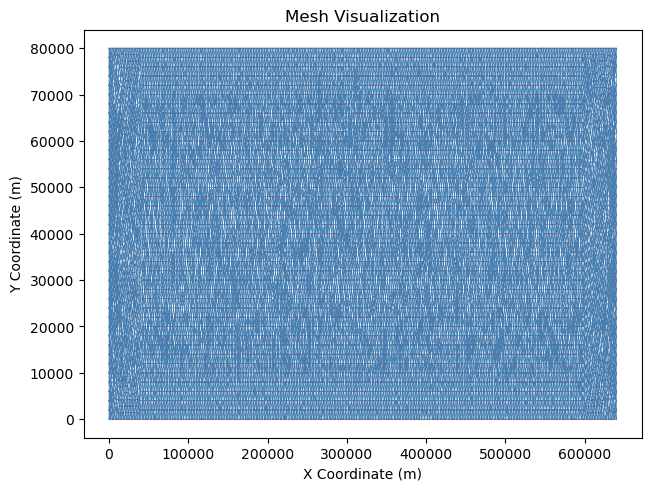

Number of nodes: 14214
Number of elements: 27706


In [8]:
fig, ax = pyissm.plot.plot_mesh2d(md, 
                                  color = 'steelblue', 
                                  linewidth = 0.5, 
                                  show_nodes = True, 
                                  node_kwargs = {'s' : .02, 
                                                 'color' : 'red', 
                                                 'alpha' : 0.5})
ax.set_xlabel('X Coordinate (m)')
ax.set_ylabel('Y Coordinate (m)')
ax.set_title('Mesh Visualization')
plt.show()
print(f'Number of nodes: {md.mesh.numberofvertices}')
print(f'Number of elements: {md.mesh.numberofelements}')

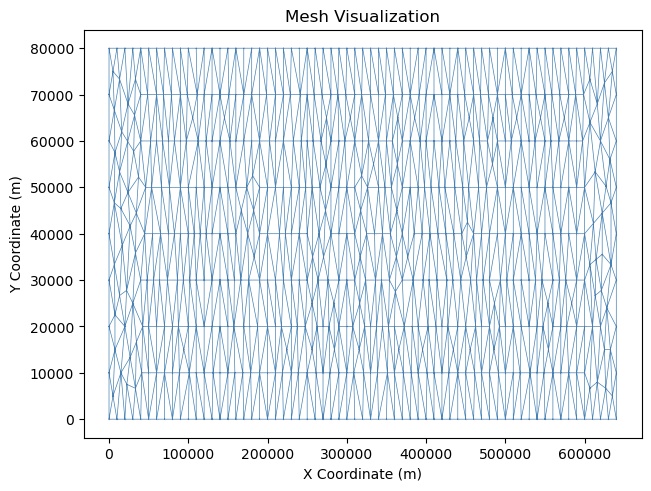

Number of nodes: 646
Number of elements: 1146


In [ ]:
fig, ax = pyissm.plot.plot_mesh2d(md, 
                                  color = 'steelblue', 
                                  linewidth = 0.5, 
                                  show_nodes = True, 
                                  node_kwargs = {'s' : .02, 
                                                 'color' : 'red', 
                                                 'alpha' : 0.5})
ax.set_xlabel('X Coordinate (m)')
ax.set_ylabel('Y Coordinate (m)')
ax.set_title('Mesh Visualization')
plt.show()
print(f'Number of nodes: {md.mesh.numberofvertices}')
print(f'Number of elements: {md.mesh.numberofelements}')

Okay, so here we have a domain that is 600km by 80km - and we can adjust the maximum length of the gridpoints as desired. 

## 7. Parameterization: where `Mismip.py` enters

The next stage loads the mesh and calls:

```python
md = setmask(md, '', '')
md = parameterize(md, './Mismip.py')
```

`parameterize` executes `Mismip.py` in a context where `md` already exists. That is why `Mismip.py` can directly modify `md.geometry`, `md.friction`, `md.materials`, and other fields without defining `md` itself.

## 8. Geometry in `Mismip.py`

The geometry is analytic and mesh-dependent. It uses the mesh coordinates `md.mesh.x` and `md.mesh.y`.

The script computes:

- `bx`: a polynomial bed shape in the flow direction `x`
- `by`: a transverse shape in `y`
- `by0`: the transverse term evaluated at `y = 0`
- `bed`: clipped with a lower bound of `-720`
- `surface`: clipped with a lower bound of `10`
- `base`: the maximum of bed and `-90`
- `thickness`: `surface - base`

This is the first point where the abstract mesh becomes an ice geometry.

In [9]:
md = pyissm.model.io.load_model(GADI_CONFIG["rundir"] + "/" + modelname + ".issm")
md.mesh

   2D tria Mesh (horizontal):
      Elements and vertices:
         numberofelements       : 27706           -- number of elements
         numberofvertices       : 14214           -- number of vertices
         elements               : (27706, 3)      -- vertex indices of the mesh elements
         x                      : (14214,)        -- vertices x coordinate [m]
         y                      : (14214,)        -- vertices y coordinate [m]
         edges                  : (41919, 4)      -- edges of the 2d mesh (vertex1 vertex2 element1 element2)
         numberofedges          : 41919           -- number of edges of the 2d mesh

      Properties:
         vertexonboundary       : (14214,)        -- vertices on the boundary of the domain flag list
         segments               : (720, 3)        -- edges on domain boundary (vertex1 vertex2 element)
         segmentmarkers         : (720,)          -- number associated to each segment
         vertexconnectivity     : N/A       

In [10]:
md = pyissm.model.param.parameterize(md, './Mismip.py')

      creating thickness
      creating drag
      creating flow law parameter
      boundary conditions for diagnostic model
      forcing conditions


/g/data/au88/jr5971/pyISSM/src/pyissm/model/bc.py:102: UserWarning: pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.
  warnings.warn('pyissm.model.bc._set_sb_dirichlet_bc: No observed velocities found. Setting stressbalance model boundary conditions as 0.')
/g/data/au88/jr5971/pyISSM/src/pyissm/model/classes/smb.py:131: UserWarning: pyissm.model.classes.smb.default: smb.mass_balance not specified -- set to 0.
  warnings.warn('pyissm.model.classes.smb.default: smb.mass_balance not specified -- set to 0.')
/g/data/au88/jr5971/pyISSM/src/pyissm/model/classes/basalforcings.py:141: UserWarning: pyissm.model.classes.basalforcings.default: no groundedice_melting_rate specified -- values set as 0
  warnings.warn('pyissm.model.classes.basalforcings.default: no groundedice_melting_rate specified -- values set as 0')
/g/data/au88/jr5971/pyISSM/src/pyissm/model/classes/basalforcings.py:145: UserWarning: pyissm.model.classes.b

Alrighty, well that has seemed to work! We now have a working `Mismip.py` parameterisation file for this MISMIP configuration. 

## 12. First solve: transient SSA spin-up

After parameterization, `runme.py` starts with an SSA transient solve:

```python
md = setflowequation(md, 'SSA', 'all')
md.timestepping.time_step = 1
md.timestepping.final_time = 200000
```

This is a long relaxation run. Its purpose is to move from the analytic initial geometry and velocity guesses toward a dynamically adjusted state.

The important choices are:

- flow equation: `SSA`
- time step: 1 year
- final time: 200,000 years
- output/checkpoint frequency: every 2,000 years
- stress-balance max iterations: 30
- relative tolerance: 1

The output is saved both through the organizer and, for the first viscous case, exported to NetCDF.

In [11]:
md = pyissm.model.param.set_flow_equation(md, SSA = 'all')
md

   ISSM Model Class                         
                                            
               mesh:  mesh properties         
               mask:  defines grounded and floating elements 
           geometry:  surface elevation, bedrock topography, ice thickness, ... 
          constants:  physical constants      
                smb:  surface mass balance    
      basalforcings:  bed forcings            
          materials:  material properties     
             damage:  damage propagation laws 
           friction:  basal friction / drag properties 
       flowequation:  flow equations          
       timestepping:  timestepping for transient models 
     initialization:  initial guess / state   
              rifts:  rifts properties        
         solidearth:  solidearth inputs and settings 
                dsl:  dynamic sea level       
              debug:  debugging tools (valgrind, gprof 
            verbose:  verbosity level in solve 
           settings:  sett

In [12]:
import numpy as np

In [13]:
modelname

'2km_viscous'

In [14]:
md.timestepping.time_step = 1
md.timestepping.final_time = 200
md.settings.output_frequency = 20
md.settings.checkpoint_frequency = 20
md.stressbalance.maxiter = 30
md.settings.solver_residue_threshold = np.nan
md.miscellaneous.name = "MISMIP_" + modelname + "_Tss1-200y"

# pyissm.model.execute.solve expects md.cluster to be a cluster object, not a string.
md.cluster = pyissm.model.classes.cluster.gadi()
md.cluster.login = GADI_CONFIG["login"]
md.cluster.project = GADI_CONFIG["project"]
md.cluster.storage = GADI_CONFIG["storage"]
md.cluster.executionpath = GADI_CONFIG["executionpath"]
md.cluster.codepath = GADI_CONFIG["codepath"]
md.cluster.np = GADI_CONFIG["numnodes"] * GADI_CONFIG["cpuspernode"]
md.cluster.memory = GADI_CONFIG["memory_gb"]
md.cluster.queue = GADI_CONFIG["queue"]
md.cluster.time = GADI_CONFIG["time_minutes"]
md.cluster.moduleuse = GADI_CONFIG["moduleuse"]
md.cluster.moduleload = GADI_CONFIG["moduleload"]

print(md.cluster)


ISSM - cluster.gadi Class


In [ ]:
%%time
md = pyissm.model.execute.solve(
    
    md = md,
    solution_string = "tr",
    load_only = False,
    runtime_name = False,
)


Checking model consistency...
Marshalling for MISMIP_2km_viscous_Tss1-200y.bin


/g/data/au88/jr5971/pyISSM/src/pyissm/model/classes/qmu.py:112: UserWarning: pyissm.model.classes.qmu::qmu not yet implemented. Turning off qmu.
  warnings.warn('pyissm.model.classes.qmu::qmu not yet implemented. Turning off qmu.')


Transferring MISMIP_2km_viscous_Tss1-200y.tar.gz to cluster gadi-cpu-clx-2359.gadi.nci.org.au...
Launching job MISMIP_2km_viscous_Tss1-200y on cluster gadi-cpu-clx-2359.gadi.nci.org.au...
167692539.gadi-pbs
Waiting for job to complete...


In [30]:
help(pyissm.model.execute.load_results_from_disk)

Help on function load_results_from_disk in module pyissm.model.execute:

load_results_from_disk(md, filename)
    Load simulation results from disk into a model object.
    
    This function loads results from a binary file or processes QMU (Quantification 
    of Margins and Uncertainties) results depending on the model configuration. 
    It handles result parsing, error checking, log file reading, and result 
    organization within the model structure.
    
    Parameters
    ----------
    md : object
        Model object containing simulation parameters, results structure, and 
        configuration settings. Must have attributes like `qmu`, `results`, 
        `miscellaneous`, and `private`.
    filename : str
        Path to the binary file containing simulation results to be loaded.
    
    Returns
    -------
    object
        The modified model object with results loaded into the `md.results` 
        attribute and solution type set in `md.private.solution`.
    
    Rais

In [45]:
md.results.TransientSolution.Vel.shape

(646,)

In [29]:
md.cluster.name

'gadi-cpu-clx-0900.gadi.nci.org.au'

## Exploring the temporal convergence of the model

In [ ]:
md_test = pyissm.model.execute.load_results_from_disk(md, filename='/scratch/au88/jr5971/issm_runs/MISMIP_10km_viscous_Tss1-200y/MISMIP_10km_viscous_Tss1-200y.outbin') #, "TransientSolution", 0)    

In [68]:
pyissm.model.io.save_model(md_test, GADI_CONFIG["rundir"] + "/" + modelname + "_loaded.issm.nc")

In [48]:
md_test.results.TransientSolution.Vel.shape

(11, 646)

In [49]:
ts = md_test.results.TransientSolution
ts

  1x11 array with fields:

    step
    time
    SmbMassBalance
    StressbalanceConvergenceNumSteps
    Vx
    Vy
    Vel
    Pressure
    Thickness
    Surface
    Base
    MaskOceanLevelset
    SolutionType
    errlog
    outlog

In [64]:
ts.StressbalanceConvergenceNumSteps

[array([11.]), None, None, None, None, None, None, None, None, None, None]

In [52]:
ts_vel = ts.Vel
ts_thick = ts.Thickness

In [57]:
import matplotlib.pyplot as plt

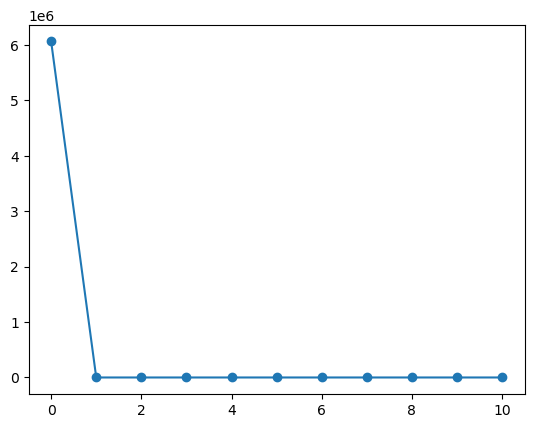

In [65]:
plt.plot(np.max(ts_vel, axis=1), marker='o')

Alrighty, well I've now got access to a dataset that has both space and time info. Now I think it's probably a good idea to make some plots. 

In [ ]:
pyissm.model.io.load_model.

In [17]:
pyissm.model.io.save_model(md, GADI_CONFIG["rundir"] + "/" + modelname + "_testrun.nc")

In [14]:
md = pyissm.model.io.load_model(GADI_CONFIG["rundir"] + "/" + modelname + "_testrun.nc")

ℹ️ Processing results group: TransientSolution


In [15]:
print(type(md.results.TransientSolution))
print(len(md.results.TransientSolution))
print([md.results.TransientSolution[i].step for i in range(len(md.results.TransientSolution))])


<class 'pyissm.model.classes.results.solution'>


TypeError: object of type 'solution' has no len()

In [16]:
ts = md.results.TransientSolution
ts

    SolutionType: TransientSolution
    errlog: 
    outlog: 
    Base: [349.83232493  -7.00371359  -6.82967419 349.83232493 349.02297167
 346.60000267 342.57866536 336.9842889  329.85215925 321.22734445
 311.1644698  299.72744318 286.9891304  273.03098063 257.94260181
 241.82128621 224.77148602 206.90423888 188.33654368 169.19068621
 149.59351497 129.67566701 109.57074386  89.41443742  69.343606
  49.49530041  30.00573999  11.00923885  -2.56432996  -2.6725974
  -2.79125159  -2.89717088  -3.04285403  -3.18505253  -3.32518952
  -3.45960691  -3.59683155  -3.74414671  -3.88500902  -4.0268306
  -4.16605222  -4.30889982  -4.45025932  -4.58814862  -4.72677157
  -4.86955491  -5.00533905  -5.14416336  -5.28405463  -5.41472642
  -5.54351083  -5.67548906  -5.78592846  -5.92253247  -6.05536634
  -6.19457976  -6.32956352  -6.4583418   -6.5748663   -6.7117299
  -6.85254855  -6.9877123   -7.12181857  -7.28035062  -7.21732097
  -7.38983981  -7.53666907 -10.64182345 -16.06056509 -21.1660939
 -22.37012

In [18]:
ts[-1]

    SolutionType                    : TransientSolution
    errlog                          : 
    outlog                          : 
    Base                            : [349.83232493  -7.00371359  -6.82967419 349.83232493 349.02297167
 346.60000267 342.57866536 336.9842889  329.85215925 321.22734445
 311.1644698  299.72744318 286.9891304  273.03098063 257.94260181
 241.82128621 224.77148602 206.90423888 188.33654368 169.19068621
 149.59351497 129.67566701 109.57074386  89.41443742  69.343606
  49.49530041  30.00573999  11.00923885  -2.56432996  -2.6725974
  -2.79125159  -2.89717088  -3.04285403  -3.18505253  -3.32518952
  -3.45960691  -3.59683155  -3.74414671  -3.88500902  -4.0268306
  -4.16605222  -4.30889982  -4.45025932  -4.58814862  -4.72677157
  -4.86955491  -5.00533905  -5.14416336  -5.28405463  -5.41472642
  -5.54351083  -5.67548906  -5.78592846  -5.92253247  -6.05536634
  -6.19457976  -6.32956352  -6.4583418   -6.5748663   -6.7117299
  -6.85254855  -6.9877123   -7.12181857  

In [29]:
list(ts.steps[0].__dict__.keys())

['SolutionType',
 'errlog',
 'outlog',
 'Base',
 'MaskOceanLevelset',
 'Pressure',
 'SmbMassBalance',
 'StressbalanceConvergenceNumSteps',
 'Surface',
 'Thickness',
 'Vel',
 'Vx',
 'Vy',
 'step',
 'time']

In [35]:
ts.steps[0].get_fieldnames()

dict_keys(['SolutionType', 'errlog', 'outlog', 'Base', 'MaskOceanLevelset', 'Pressure', 'SmbMassBalance', 'StressbalanceConvergenceNumSteps', 'Surface', 'Thickness', 'Vel', 'Vx', 'Vy', 'step', 'time'])

In [30]:
list(ts[0].get_fieldnames())

['SolutionType',
 'errlog',
 'outlog',
 'Base',
 'MaskOceanLevelset',
 'Pressure',
 'SmbMassBalance',
 'StressbalanceConvergenceNumSteps',
 'Surface',
 'Thickness',
 'Vel',
 'Vx',
 'Vy',
 'step',
 'time']

In [36]:
ts.time

1.0

In [19]:
md_ssa.results.TransientSolution.keys()

AttributeError: 'keys' not found in solution

In [18]:
len(md_ssa.results.TransientSolution)

TypeError: object of type 'solution' has no len()

In [12]:
dict(md_ssa.results.TransientSolution[0])

TypeError: 'solutionstep' object is not iterable

(<Figure size 640x480 with 1 Axes>, <Axes: xlabel='X (m)', ylabel='Y (m)'>)

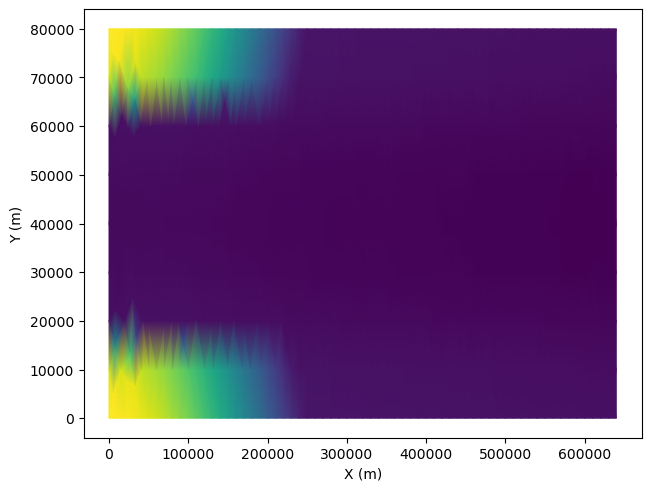

In [35]:
pyissm.plot.plot_model_field(md_ssa, md_ssa.results.TransientSolution.Base)

## 13. Restart stages

The `Transient_steadystate2`, `Transient_steadystate3`, `Transient_steadystate4`, and `Transient_steadystate5` stages all follow the same restart logic.

Each one loads the previous stage, copies the last transient result back into model fields, and runs another segment.

The copied fields are usually:

- `Vx`, `Vy`, `Vel` into `md.initialization`
- `Thickness`, `Base`, `Surface` into `md.geometry`
- `MaskOceanLevelset` into `md.mask.ocean_levelset`

This makes the next solve start from the previous final state rather than from the original analytic initialization.

In [ ]:
# Reusable pattern behind the restart stages.
#
# previous = md.results.TransientSolution[-1]
# md.initialization.vx = previous.Vx
# md.initialization.vy = previous.Vy
# md.initialization.vel = previous.Vel
# md.geometry.thickness = previous.Thickness
# md.geometry.base = previous.Base
# md.geometry.surface = previous.Surface
# md.mask.ocean_levelset = previous.MaskOceanLevelset

## 14. Extrusion stage

`Transient_extrude` creates a 3D model from a spun-up 2D model:

```python
md = md.extrude(10, 1.1)
md = setflowequation(md, 'HO', 'all')
```

This creates 10 vertical layers, with layer spacing controlled by the exponent-like second argument `1.1`.

After extrusion, the script disables thermal and SMB transients and initializes temperature to `273 K`.

## 15. Solver branch choices

Once the spin-up state exists, `runme.py` branches into solver comparisons.

| Branch | Flow equation | Mesh handling | Main purpose |
| --- | --- | --- | --- |
| `GlenSSA` | `SSA` | collapse to 2D | Shallow-shelf baseline comparison. |
| `GlenMOLHO` | `MOLHO` | collapse to 2D | Modified/layered higher-order style comparison. |
| `GlenHO` | `HO` | uses extruded model | Higher-order comparison. |
| `GlenFS` | `FS` | extrudes to 3D | Short full-Stokes-style experiment. |

All branches request diagnostic outputs such as volume, grounded area, strain rates, and masks. The exact requested outputs depend on the flow equation.

## 16. Example: current target branch is likely `GlenMOLHO`

Because `steps = [11]`, the current `runme.py` appears to target the `GlenMOLHO` block if the organizer counts stages in source order.

The logical path for that target is:

1. `Mesh_generation`
2. `Parameterization`
3. `Transient_Steadystate`
4. optional restart/spin-up stages
5. `Transient_extrude` unless using model numbers 5 or 6
6. `GlenMOLHO`

The `GlenMOLHO` branch then collapses the model, sets the flow equation to `MOLHO`, adds a stress-balance toolkit option, applies `SetMOLHOBC(md)`, and runs a 1000-year transient with monthly time steps.

In [ ]:
# Skeleton of the GlenMOLHO branch from runme.py.
#
# if modelnum in (5, 6):
#     md = org.loadmodel("Transient_Steadystate")
# else:
#     md = org.loadmodel("Transient_extrude")
#
# md.transient.requested_outputs = [
#     "default", "IceVolume", "IceVolumeAboveFloatation", "GroundedArea",
#     "VxShear", "VyShear", "VxBase", "VyBase", "VxSurface", "VySurface",
#     "VxAverage", "VyAverage", "StrainRatexx", "StrainRatexy", "StrainRateyy",
#     "StrainRateeffective", "MaskOceanLevelset", "IceMaskNodeActivation", "MaskIceLevelset",
# ]
#
# md = md.collapse()
# md = setflowequation(md, "MOLHO", "all")
# md.toolkits = toolkits.addoptions(md.toolkits, "StressbalanceAnalysis", bcgslbjacobioptions())
# md = SetMOLHOBC(md)
#
# md.timestepping.time_step = 1.0 / 12.0
# md.timestepping.final_time = 1000
# md.settings.output_frequency = 600
# md.cluster = cluster
# md.miscellaneous.name = "MISMIP_" + modelname + "_GMOLHO"
#
# md = solve(md, "tr")
# org.savemodel(md)

## 17. Enhanced and ESTAR branches

The later branches reuse the same prepared spin-up state but alter the material model.

Enhanced Glen branches use `matenhancedice(...)` and set an enhancement factor like:

```python
md.materials.rheology_E = 5.0 * np.ones(md.mesh.numberofvertices)
```

ESTAR branches use `matestar(...)` and set `rheology_Es` and `rheology_Ec`.

These branches look experimental in the current file. Several lines appear to contain typos or unresolved variables, so they should be reviewed before running.

## 18. Practical configuration checklist

Before running the model, check these choices in order:

- Pick `modelnum`: this decides resolution and friction family.
- Decide `steps`: start with upstream stages if saved models do not already exist.
- Check `ISSM_DIR`: imports depend on it.
- Check cluster paths: the current Gadi paths are user-specific.
- Confirm `Domain.exp` and `Front.exp`: `Domain.exp` is present, while `Mismip.py` references `Front.exp`.
- Run `Mesh_generation` before `Parameterization`.
- Run `Parameterization` before any solve.
- Run a spin-up before solver-comparison branches.
- Treat later enhanced/ESTAR branches as work-in-progress until syntax and missing variables are fixed.

For learning, the safest first path is usually: `Mesh_generation`, `Parameterization`, then inspect `md` before launching long transient solves.

## 19. Summary

The clean logical path is:

```text
model choice -> mesh -> physical parameterization -> spin-up -> solver branch -> comparison/analysis
```

`runme.py` gives the pipeline and branch structure. `Mismip.py` gives the physical configuration. Reading them together makes the model much easier to understand than reading either file alone.